In [ ]:
import pandas as pd
import numpy as np
import random
import librosa


df=pd.read_csv("audio_data/UrbanSound8K.csv")
df=df.drop(columns=["fsID","start","end","salience"])


class_name=dict(zip(df["classID"],df["class"]))

def get_path(row):
    return f"audio_data/fold{row["fold"]}/{row["slice_file_name"]}"

df["filepath"]=df.apply(get_path, axis=1)

def augment_audio(audio, sr, duration=4):
    if random.random() < 0.4:
        noise = np.random.randn(len(audio))
        audio = audio + 0.005 * noise

    if random.random() < 0.4:
        shift = int(sr * random.uniform(-0.2, 0.2))
        audio = np.roll(audio, shift)

    if random.random() < 0.4:
        audio = librosa.effects.pitch_shift(audio, sr=sr, n_steps=random.uniform(-2, 2))

    if random.random() < 0.4:
        rate = random.uniform(0.8, 1.2)
        audio = librosa.effects.time_stretch(audio, rate=rate)

    if random.random() < 0.4:
        audio = audio * random.uniform(0.7, 1.3)

    if len(audio) < sr*duration:
        pad_width= sr*duration - len(audio)
        audio = np.pad(audio, (0, pad_width), mode='constant')
    else:
        audio = audio[:sr*duration]

    return audio

def mel_spectrogram(filepath, n_mels=128, duration=4, sr=16000):
    audio,_ = librosa.load(filepath, sr=sr, duration=duration)

    if len(audio) < sr*duration:
        pad_width= sr*duration - len(audio)
        audio = np.pad(audio, (0, pad_width), mode='constant')
    else:
        audio = audio[:sr*duration]

    audio = augment_audio(audio, sr)

    mel = librosa.feature.melspectrogram(y=audio, sr=sr, n_mels=n_mels)

    mel_db = librosa.power_to_db(mel)

    mel_db = np.nan_to_num(mel_db)

    mel_db = (mel_db - mel_db.mean()) / (mel_db.std() + 1e-6)

    return np.expand_dims(mel_db, axis=-1)

df['features']=df['filepath'].apply(mel_spectrogram)




In [54]:
np.save("mel_features.npy", np.array(df["features"].tolist()))
df[['classID','class']].to_csv("labels.csv", index=False)


In [1]:
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd

x = np.load("mel_features.npy")
labels = pd.read_csv("labels.csv")

y=np.array(labels['classID'].tolist())

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.1,random_state=42,stratify=y)
x_train, x_val, y_train, y_val = train_test_split(
    x_train, y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)


n_classes = labels['classID'].nunique()
y_train_encoded = to_categorical(y_train, num_classes=n_classes)
y_val_encoded = to_categorical(y_val, num_classes=n_classes)
y_test_encoded = to_categorical(y_test, num_classes=n_classes)





    


In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, GaussianNoise, Input
from sklearn.metrics import accuracy_score
from tensorflow.keras.callbacks import EarlyStopping

model_audio = Sequential([
    Input(shape=x_train[0].shape),
    GaussianNoise(0.1),

    Conv2D(32, (3,3), activation='relu', padding='same'),
    MaxPooling2D(),

    Conv2D(64, (3,3), activation='relu', padding='same'),
    MaxPooling2D(),

    Conv2D(128, (3,3), activation='relu', padding='same'),
    MaxPooling2D(),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(n_classes, activation='softmax')
])

model_audio.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6)

model_audio.fit(x_train, y_train_encoded, epochs=30, batch_size=32, validation_data=(x_val, y_val_encoded), callbacks=[early_stop, reduce_lr])

pred = model_audio.predict(x_test)

pred_labels = np.argmax(pred, axis=1)

acc = accuracy_score(y_test, pred_labels)

print("accuracy:",acc)

Epoch 1/30
197/197 ━━━━━━━━━━━━━━━━━━━━ 37s 181ms/step - accuracy: 0.3081 - loss: 1.9320 - val_accuracy: 0.6330 - val_loss: 1.1242 - learning_rate: 0.0010
Epoch 2/30
197/197 ━━━━━━━━━━━━━━━━━━━━ 37s 188ms/step - accuracy: 0.6070 - loss: 1.1595 - val_accuracy: 0.7265 - val_loss: 0.8684 - learning_rate: 0.0010
Epoch 3/30
197/197 ━━━━━━━━━━━━━━━━━━━━ 38s 195ms/step - accuracy: 0.7203 - loss: 0.8518 - val_accuracy: 0.7818 - val_loss: 0.6546 - learning_rate: 0.0010
Epoch 4/30
197/197 ━━━━━━━━━━━━━━━━━━━━ 40s 203ms/step - accuracy: 0.7929 - loss: 0.6128 - val_accuracy: 0.7729 - val_loss: 0.7039 - learning_rate: 0.0010
Epoch 5/30
197/197 ━━━━━━━━━━━━━━━━━━━━ 42s 211ms/step - accuracy: 0.8313 - loss: 0.5083 - val_accuracy: 0.8282 - val_loss: 0.5578 - learning_rate: 0.0010
Epoch 6/30
197/197 ━━━━━━━━━━━━━━━━━━━━ 40s 204ms/step - accuracy: 0.8711 - loss: 0.3959 - val_accuracy: 0.8289 - val_loss: 0.5806 - learning_rate: 0.0010
Epoch 7/30
197/197 ━━━━━━━━━━━━━━━━━━━━ 41s 206ms/step - accuracy: 0.8

In [8]:
model_audio.save('model_audio.keras')

In [11]:
import librosa
import numpy as np
import pandas as pd
from tensorflow.keras.models import load_model

model_audio1 = load_model("model_audio.keras")
df1=pd.read_csv("audio_data/UrbanSound8K.csv")
df1=df1.drop(columns=["fsID","start","end","salience"])


class_name=dict(zip(df1["classID"],df1["class"]))

def preprocess_audio(file_path, sr=16000, n_mels=128, duration=4):

    audio, sr = librosa.load(file_path, sr=sr, duration=duration)

    if len(audio) < sr*duration:
        pad_width= sr*duration - len(audio)
        audio = np.pad(audio, (0, pad_width), mode='constant')
    else:
        audio = audio[:sr*duration]

    mel = librosa.feature.melspectrogram(
        y=audio,
        sr=sr,
        n_mels=n_mels
    )

    mel = librosa.power_to_db(mel, ref=np.max)

    mel = (mel - np.mean(mel)) / (np.std(mel) + 1e-6)

    mel = np.expand_dims(mel, axis=-1)
    mel = np.expand_dims(mel, axis=0)   
    return mel


def predict_audio(file_path):
    X = preprocess_audio(file_path)
    pred = model_audio1.predict(X)[0]

    predicted_class = np.argmax(pred)
    confidence = np.max(pred)

    print("\nPrediction:")
    print("Class:", predicted_class)
    print("Confidence:", round(confidence * 100, 2), "%")

    return class_name[predicted_class]


predict_audio("air_conditioner.wav")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step

Prediction:
Class: 0
Confidence: 99.97 %


'air_conditioner'

In [1]:
pip install sounddevice scipy


Note: you may need to restart the kernel to use updated packages.


In [ ]:
import sounddevice as sd
from scipy.io.wavfile import write
import numpy as np
import librosa

def safe_normalize(audio, threshold=0.01):
    peak = np.max(np.abs(audio))
    if peak < threshold:
        print("Silence detected — skipping normalization")
        return audio
    return audio / peak

def record_audio(filename="test.wav", duration=4, sr=16000):
    print("Recording...")
    audio = sd.rec(int(duration * sr), samplerate=sr, channels=1, dtype='float32')
    sd.wait()

    # SAFE normalization (no loud hiss)
    audio = audio.flatten()
    audio = safe_normalize(audio)

    write(filename, sr, audio.astype('float32'))
    print("Saved:", filename)



record_audio("test.wav", duration=4)


Recording...
Saved: test.wav


In [80]:
predict_audio("record.wav")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step

Prediction:
Class: 2
Confidence: 89.27 %


'children_playing'

28/28 ━━━━━━━━━━━━━━━━━━━━ 4s 56ms/step


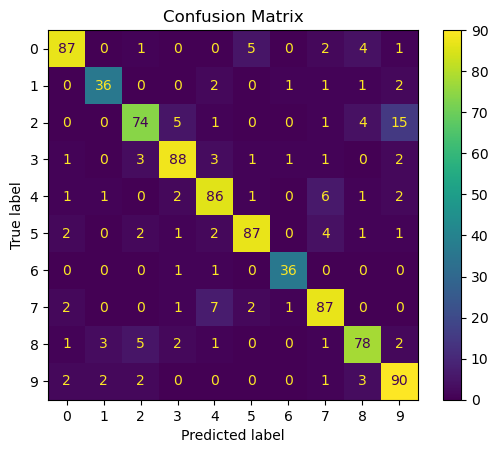

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras.models import load_model

model_audio2 = load_model("model_audio.keras")

# Predict on test data
y_pred_probs = model_audio2.predict(x_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = y_test  # original labels (not one-hot)

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix")
plt.show()


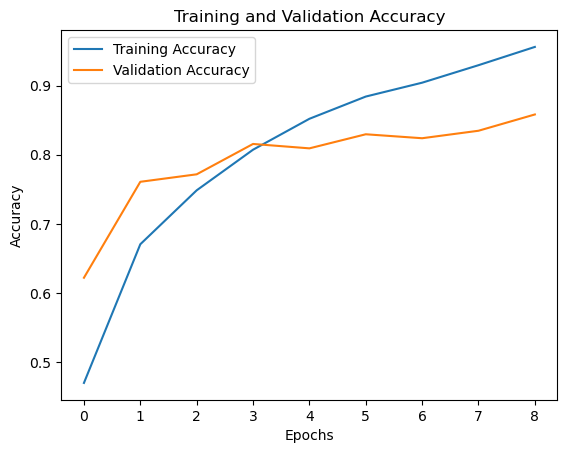

In [8]:
# Accuracy plot
plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend(['Training Accuracy', 'Validation Accuracy'])
plt.show()


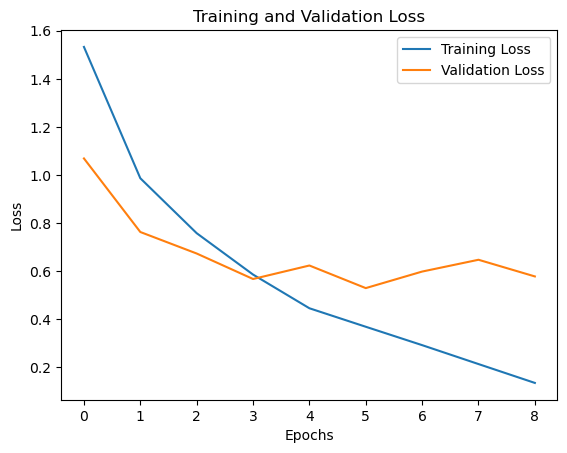

In [9]:
# Loss plot
plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend(['Training Loss', 'Validation Loss'])
plt.show()
